# Hyperopt: Space Configuration

One of the most valuable offers of Hyperopt is the flexibility it provides to create priors over the hyperparameters distributions.

Hyperopt offers:

- Multiple distributions
- Possibility to combine distributions
- Possibility to create nested spaces
- Multiple configuration ways including lists, dictionaries and tuples


## Distributions

Taken from [hp documentation](http://hyperopt.github.io/hyperopt/getting-started/search_spaces/) 

- **hp.choice**: returns one of several options (suitable for categorical hyperparams)
- **hp.randint**: returns a random integer between 0 and an upper limit
- **hp.uniform**: returns a value uniformly between specified limits
- **hp.quniform**: Returns a value like round(uniform(low, high) / q) * q

**hp.quniform** would be an equivalent of randint (if q=1), but the upper **and lower** limits can be specified. hp.quniform also offers the possibility to use bigger values of q. So if we search for the optimal number of trees in a random forest, we could search hp.quniform('n_estimators', 10, 1000, 50), in which case we would sample between 10 and 1000 trees in increments of 50.

- **hp.loguniform**: draws values from exp(uniform(low, high)) so that the logarithm of the returned value is uniformly distributed
- **hp.qloguniform**: Returns a value like round(exp(uniform(low, high)) / q) * q (similar use and cautions to hp.quniform but for log-uniform distributions)
- **hp.normal**: draws from a normal distribution with specified mu and sigma
- **hp.qnormal**: Returns a value like round(normal(mu, sigma) / q) * q
- **hp.lognormal**: Returns a value drawn according to exp(normal(mu, sigma)) so that the logarithm of the return value is normally distributed
- **hp.qlognormal**: Returns a value like round(exp(normal(mu, sigma)) / q) * q

### Important for q distributions
Another thing to notice is that q-distributions (qnormal, quniform, etc) return floats, where the value of the hyperparameter needs to be an integer (otherwise most models will return an error). Thus, some re-casting is necessary to pass this value to the models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hyperopt import hp
from hyperopt.pyll.stochastic import sample

# Distributions

## Numerical hyperparameters

In [2]:
# function to extract samples from the hyperparameter
# space and plot their distribution

def sample_and_plot(space, title):
    
    vals_ls = []
    
    for i in range(500):
        v = sample(space)
        v = v[0]['example']
        vals_ls.append(v)

    pd.Series(vals_ls).hist(bins=50)
    plt.title(title)
    plt.show()
    
    print('example values: ', vals_ls[0:5])

### randint

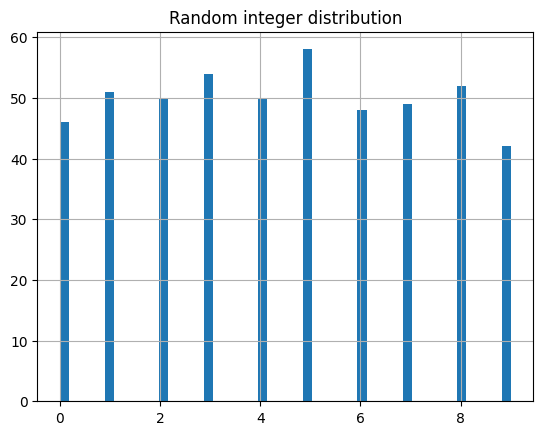

example values:  [7, 5, 2, 4, 2]


In [3]:
# randint

space = [{'example' : hp.randint('example', 10)}]

sample_and_plot(space, 'Random integer distribution')

### uniform

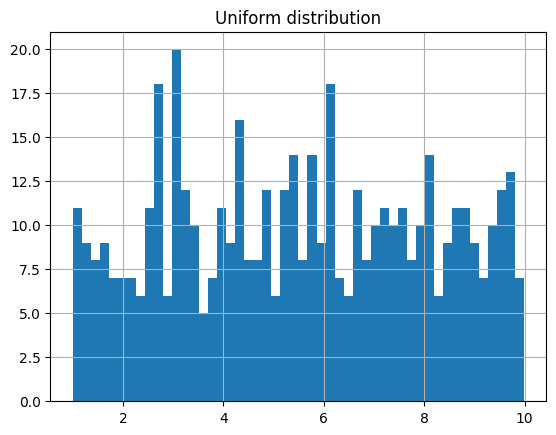

example values:  [6.786684915256639, 2.783504891265721, 9.974119829501744, 7.882375250898291, 2.0641856481017724]


In [4]:
# uniform

space = [{'example' : hp.uniform('example', 1, 10)}]

sample_and_plot(space, 'Uniform distribution')

### quniform

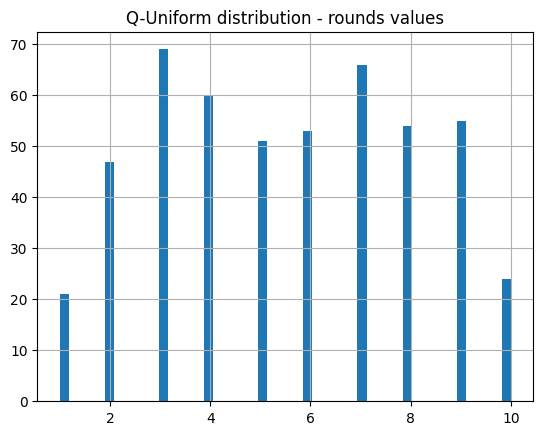

example values:  [4.0, 7.0, 7.0, 9.0, 5.0]


In [5]:
# quniform

space = [{'example' : hp.quniform('example', 1, 10, 1)}]

sample_and_plot(space, 'Q-Uniform distribution - rounds values')

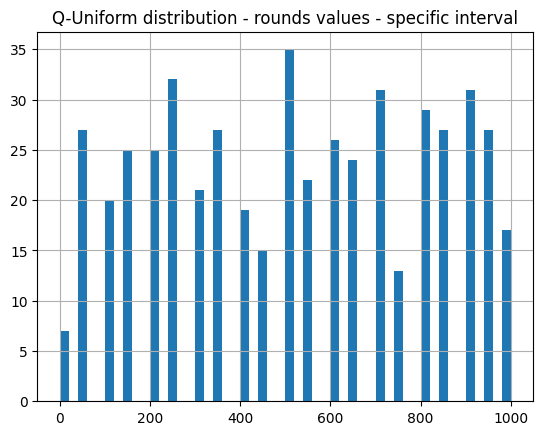

example values:  [900.0, 250.0, 650.0, 850.0, 700.0]


In [6]:
# with quniform we can change the limits (respect to randint)

space = [{'example' : hp.quniform('example', 10, 1000, 50)}]

sample_and_plot(space, 'Q-Uniform distribution - rounds values - specific interval')

### loguniform

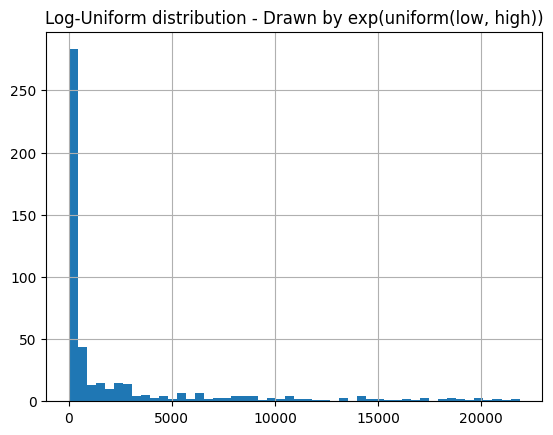

example values:  [3.0121604379168687, 275.3644503755364, 2238.194004509579, 2986.394806911607, 72.64162845404529]


In [7]:
# loguniform

space = [{'example' : hp.loguniform('example', 1, 10)}]

sample_and_plot(space, 'Log-Uniform distribution - Drawn by exp(uniform(low, high))')

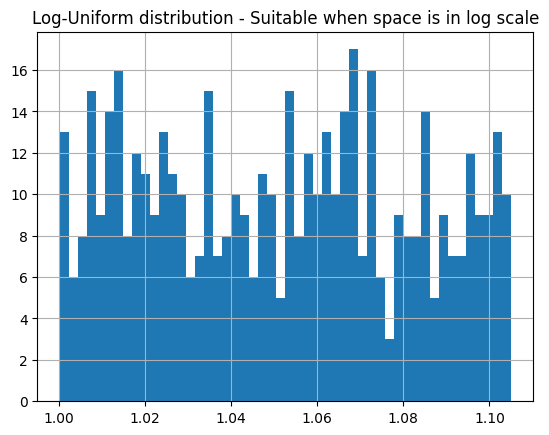

example values:  [1.021276007611988, 1.0225314889044588, 1.0604131502441794, 1.0369077735342587, 1.0428423739785806]


In [8]:
# Attention, the use of loguniform for floats < 1 is unintuitive
# (at least for me)

space = [{'example' : hp.loguniform('example', 0.000001, 0.1)}]

sample_and_plot(space, 'Log-Uniform distribution - Suitable when space is in log scale')

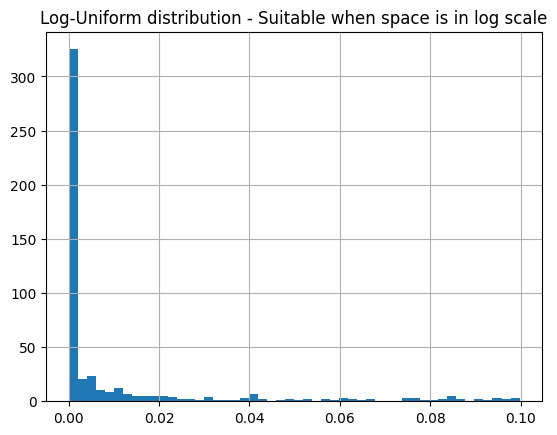

example values:  [0.001921676782339865, 1.4308576616686944e-06, 0.0006638614390039146, 9.122947992321072e-06, 2.9116093162805662e-06]


In [9]:
# if we want a log distribution over 0.000001, 0.1
# we need to enter it like this:

space = [{'example' : hp.loguniform('example', np.log(0.000001), np.log(0.1))}]

sample_and_plot(space, 'Log-Uniform distribution - Suitable when space is in log scale')

### q log uniform

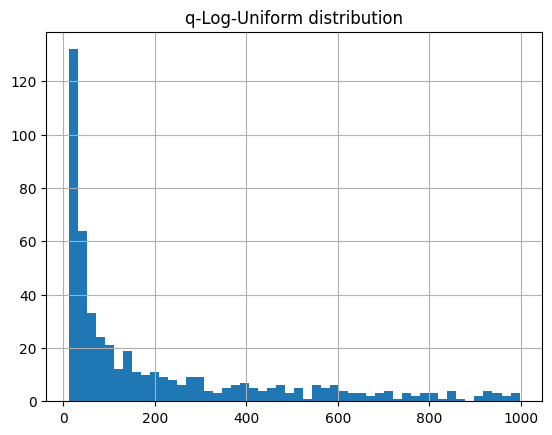

example values:  [58.68034508142219, 222.98531130940432, 39.12023005428146, 301.2257714179672, 211.2492422931199]


In [10]:
# qloguniform
# example we want to sample trees between 10 and 1000, in increments of 50
# but we think that better values are closer to smaller number of trees,
# so we want to sample more of those

space = [{'example': hp.qloguniform('example', np.log(10), np.log(1000), np.log(50))}]

sample_and_plot(space, 'q-Log-Uniform distribution')

### normal

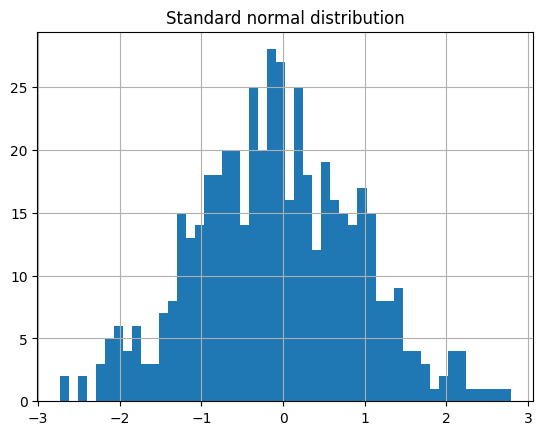

example values:  [-0.11286755193739945, -0.10061569342845536, 1.0098458346008732, 0.12209603274592146, -1.437451479488293]


In [11]:
# normal

# the standard normal
space = [{'example': hp.normal('example', 0, 1)}]

sample_and_plot(space, 'Standard normal distribution')

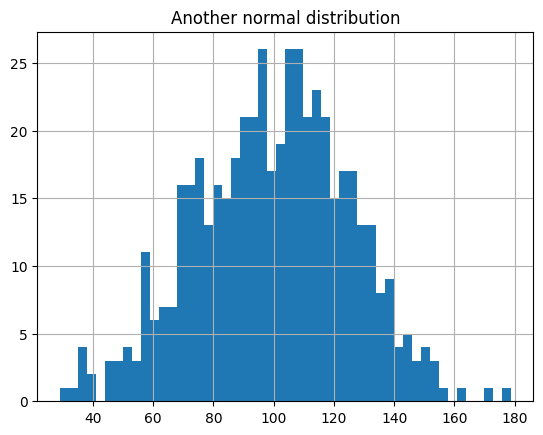

example values:  [71.05341157267172, 73.89831692614133, 130.6364819888361, 64.77159635754998, 67.89264175070267]


In [12]:
# normal

space = [{'example': hp.normal('example', 100, 25)}]

sample_and_plot(space, 'Another normal distribution')

### q normal

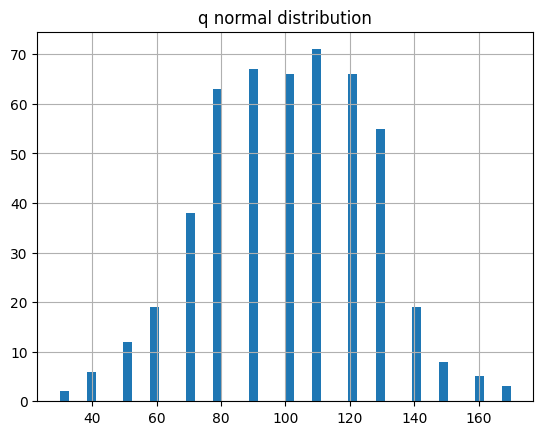

example values:  [130.0, 160.0, 90.0, 100.0, 110.0]


In [13]:
# qnormal
# same as previous but at discrete intervals

space = [{'example': hp.qnormal('example', 100, 25, 10)}]

sample_and_plot(space, 'q normal distribution')

### log normal

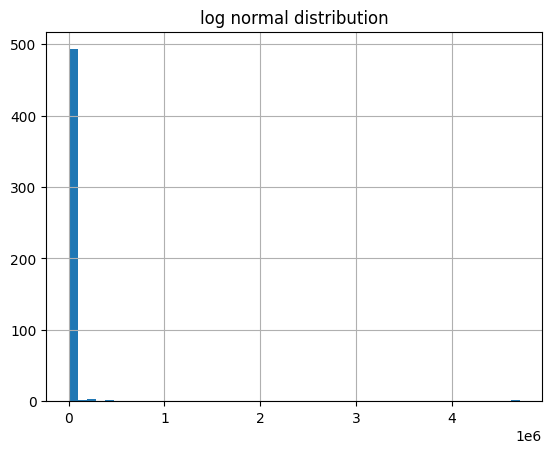

example values:  [31.864820753898588, 532.5611914435731, 3801.1594746284095, 14.400426044889633, 1231.678762893521]


In [14]:
# lognormal

space = [{'example': hp.lognormal('example', np.log(100), np.log(25))}]

sample_and_plot(space, 'log normal distribution')

### q log normal

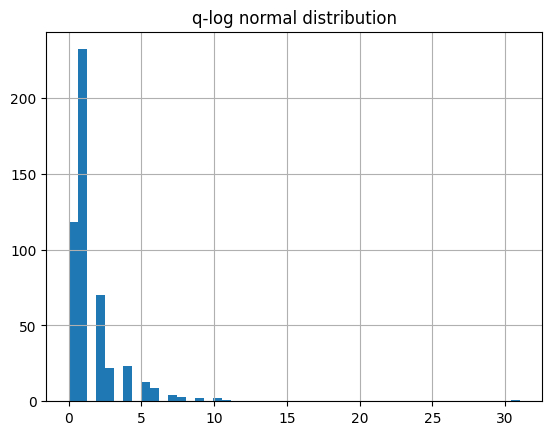

example values:  [6.0, 1.0, 1.0, 1.0, 1.0]


In [15]:
# q-lognormal

space = [{'example': hp.qlognormal('example', 0, 1, 1)}]

sample_and_plot(space, 'q-log normal distribution')

## Categorical hyperparameters

In [16]:
def sample_and_plot(space, title):
    
    vals_ls = []
    
    for i in range(500):
        v = sample(space)
        v = v[0]['example']
        vals_ls.append(v)

    pd.Series(vals_ls).value_counts().plot.bar()
    plt.title(title)
    plt.ylabel('Number of draws')
    plt.show()
    
    print('example values: ', vals_ls[0:5])

### choice

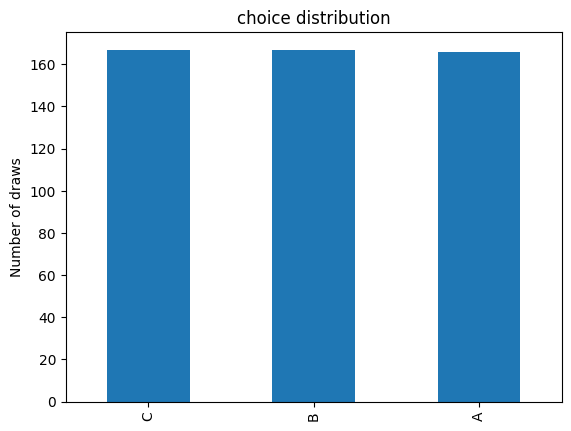

example values:  ['C', 'A', 'A', 'A', 'B']


In [17]:
# choice

space = [{'example': hp.choice('example', ['A', 'B', 'C'])}]

sample_and_plot(space, 'choice distribution')

### pchoice

Draws from a list with a user specified probability.

In [18]:
# pchoice

# example from the Hyperopt article

space = hp.pchoice('example', [
    (0.8, {'use_var': 'x', 'x': hp.normal('x', 0, 1)}),
    (0.2, {'use_var': 'y', 'y': hp.uniform('y', 1, 3)})])

In [19]:
# draw samples from space

for i in range(20):
        v = sample(space)
        print(v)

{'use_var': 'y', 'y': 2.250494099979859}
{'use_var': 'x', 'x': 0.1657824029713113}
{'use_var': 'x', 'x': 1.3675289790897616}
{'use_var': 'x', 'x': 0.9865326154500785}
{'use_var': 'x', 'x': 0.7824363751152477}
{'use_var': 'x', 'x': -1.7157417745666592}
{'use_var': 'x', 'x': -1.9082440212583307}
{'use_var': 'x', 'x': -0.6792978307445121}
{'use_var': 'x', 'x': 0.15781893106489026}
{'use_var': 'x', 'x': 0.16757153990013976}
{'use_var': 'x', 'x': -1.2537056541761522}
{'use_var': 'y', 'y': 2.9423084612065806}
{'use_var': 'x', 'x': 1.1104346280740185}
{'use_var': 'x', 'x': 0.8226625159464059}
{'use_var': 'x', 'x': 0.06067096902219572}
{'use_var': 'x', 'x': -1.8228965837188424}
{'use_var': 'x', 'x': 0.2407489371135195}
{'use_var': 'x', 'x': -0.0961958442689815}
{'use_var': 'x', 'x': -0.08465930001758394}
{'use_var': 'x', 'x': -0.6752710933812295}


In [20]:
# our own example, realistic, 

# if we want to sample
# a loss function but think that deviance is likely better
# than exponential

space = hp.pchoice('example', [
    (0.8, {'loss': 'deviance'}),
    (0.2, {'loss': 'exponential'})])

# draw samples from space

for i in range(20):
        v = sample(space)
        print(v)

{'loss': 'deviance'}
{'loss': 'exponential'}
{'loss': 'deviance'}
{'loss': 'exponential'}
{'loss': 'deviance'}
{'loss': 'exponential'}
{'loss': 'deviance'}
{'loss': 'deviance'}
{'loss': 'deviance'}
{'loss': 'deviance'}
{'loss': 'deviance'}
{'loss': 'deviance'}
{'loss': 'deviance'}
{'loss': 'deviance'}
{'loss': 'deviance'}
{'loss': 'deviance'}
{'loss': 'deviance'}
{'loss': 'deviance'}
{'loss': 'deviance'}
{'loss': 'deviance'}


In [21]:
# our own example, continuing from choice

space = hp.pchoice('example', [
    (0.8, {'use_var': 'x', 'x': hp.choice('a', ['A', 'B'])}),
    (0.2, {'use_var': 'y', 'y': hp.choice('a', ['C', 'D'])})])

In [22]:
# draw samples from space

for i in range(20):
        v = sample(space)
        print(v)

{'use_var': 'x', 'x': 'A'}
{'use_var': 'x', 'x': 'A'}
{'use_var': 'x', 'x': 'A'}
{'use_var': 'x', 'x': 'B'}
{'use_var': 'x', 'x': 'A'}
{'use_var': 'x', 'x': 'A'}
{'use_var': 'x', 'x': 'B'}
{'use_var': 'x', 'x': 'A'}
{'use_var': 'x', 'x': 'B'}
{'use_var': 'x', 'x': 'A'}
{'use_var': 'x', 'x': 'A'}
{'use_var': 'x', 'x': 'A'}
{'use_var': 'x', 'x': 'A'}
{'use_var': 'x', 'x': 'A'}
{'use_var': 'x', 'x': 'B'}
{'use_var': 'x', 'x': 'A'}
{'use_var': 'x', 'x': 'B'}
{'use_var': 'x', 'x': 'B'}
{'use_var': 'x', 'x': 'B'}
{'use_var': 'x', 'x': 'A'}


In [23]:
# capture data in a dataframe

vals_ls = []
for i in range(500):
        v = sample(space)
        vals_ls.append(v)
        
v = pd.DataFrame(vals_ls)
v.head()

,use_var,x,y
0,x,A,NaN
1,x,B,NaN
2,x,A,NaN
3,x,A,NaN
4,x,A,NaN


In [24]:
v['use_var'].value_counts(normalize=True)

use_var
x    0.786
y    0.214
Name: proportion, dtype: float64

In [25]:
v['x'].value_counts(normalize=True, dropna=True)

x
A    0.516539
B    0.483461
Name: proportion, dtype: float64

In [26]:
v['x'].value_counts(normalize=True, dropna=False)

x
A      0.406
B      0.380
NaN    0.214
Name: proportion, dtype: float64

In [27]:
v['y'].value_counts(normalize=True)

y
D    0.53271
C    0.46729
Name: proportion, dtype: float64

In [28]:
v['y'].value_counts(normalize=True, dropna=False)

y
NaN    0.786
D      0.114
C      0.100
Name: proportion, dtype: float64

## Nested spaces

In [29]:
space = hp.choice('classifier_type', [
    {
        'type': 'naive_bayes',
    },
    {
        'type': 'svm',
        'C': hp.lognormal('svm_C', 0, 1),
        'kernel': hp.choice('svm_kernel', [
            {'ktype': 'linear'},
            {'ktype': 'RBF', 'width': hp.lognormal('svm_rbf_width', 0, 1)},
            ]),
    },
    {
        'type': 'dtree',
        'criterion': hp.choice('dtree_criterion', ['gini', 'entropy']),
        'max_depth': hp.choice('dtree_max_depth',
            [None, hp.qlognormal('dtree_max_depth_int', 3, 1, 1)]),
        'min_samples_split': hp.qlognormal('dtree_min_samples_split', 2, 1, 1),
    },
    ])

In [30]:
for i in range(20):
        v = sample(space)
        print(v)
        print()

{'C': 0.9648373878156122, 'kernel': {'ktype': 'RBF', 'width': 3.078211587568974}, 'type': 'svm'}

{'C': 0.21900666363761365, 'kernel': {'ktype': 'linear'}, 'type': 'svm'}

{'type': 'naive_bayes'}

{'C': 2.30000487360731, 'kernel': {'ktype': 'RBF', 'width': 0.3516416535467552}, 'type': 'svm'}

{'type': 'naive_bayes'}

{'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 9.0, 'type': 'dtree'}

{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 29.0, 'type': 'dtree'}

{'C': 0.1821111178690828, 'kernel': {'ktype': 'RBF', 'width': 2.4494699163888645}, 'type': 'svm'}

{'C': 2.4993075590478884, 'kernel': {'ktype': 'linear'}, 'type': 'svm'}

{'type': 'naive_bayes'}

{'type': 'naive_bayes'}

{'C': 0.5704179033847916, 'kernel': {'ktype': 'linear'}, 'type': 'svm'}

{'C': 1.2218918974096975, 'kernel': {'ktype': 'RBF', 'width': 2.5204933010342305}, 'type': 'svm'}

{'type': 'naive_bayes'}

{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 4.0, 'type': 'dtree'}

{'t